<a href="https://colab.research.google.com/github/rp2535706-tech/1stblog/blob/main/Human.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  classification_report, confusion_matrix
xapi_df = pd.read_csv('xAPI-Edu-Data.csv')
student_perf_df = pd.read_csv('StudentsPerformance.csv')
print("Datasets Loaded Successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'xAPI-Edu-Data.csv'

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os # For checking files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# --- STEP 1: Check if files exist ---
if not os.path.exists('xAPI-Edu-Data.csv') or not os.path.exists('StudentsPerformance.csv'):
    print("❌ ERROR: Files not found in the sidebar!")
    print("👉 Mitra, please click the FOLDER icon on the left and upload your 2 CSV files now.")
else:
    # --- STEP 2: Load Datasets ---
    xapi_df = pd.read_csv('xAPI-Edu-Data.csv')
    student_perf_df = pd.read_csv('StudentsPerformance.csv')
    print("✅ Datasets Loaded Successfully!")

    # --- STEP 3: Basic Analysis (So Ma'am can see results) ---
    print("\n--- Behavioral Data Summary ---")
    print(xapi_df['Class'].value_counts())

    # Simple Plot to test
    plt.figure(figsize=(6,4))
    sns.countplot(x='Class', data=xapi_df, hue='Class', palette='viridis')
    plt.title('Distribution of Performance Classes')
    plt.show()

❌ ERROR: Files not found in the sidebar!
👉 Mitra, please click the FOLDER icon on the left and upload your 2 CSV files now.


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import  classification_report, confusion_matrix
xapi_df = pd.read_csv('xAPI-Edu-Data.csv')
student_perf_df = pd.read_csv('StudentsPerformance.csv')
print("Datasets Loaded Successfully!")




Datasets Loaded Successfully!


In [17]:
le = LabelEncoder()
xapi_clean = xapi_df.copy()
for col in xapi_clean.select_stypes(include=['object']).columns:
  xapi_clean[col] = le.fit_trasform(xapi_clean[col])
  student_clean = student_perf_df.copy()
  for col in student_clean.select_dttypes(include=['object']).columns:
    student_clean[col] = le.fit_transform(student_clean[col])


AttributeError: 'DataFrame' object has no attribute 'select_stypes'

In [18]:
# 1. Check for missing values in both datasets
print("Missing values in Behavioral Data:")
print(xapi_df.isnull().sum())

print("\nMissing values in Student Performance Data:")
print(student_perf_df.isnull().sum())

# 2. Check the data types (to see what needs to be changed to numbers later)
print("\nData Types for Behavioral Data:")
print(xapi_df.dtypes)

Missing values in Behavioral Data:
gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

Missing values in Student Performance Data:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Data Types for Behavioral Data:
gender                      object
NationalITy                 object
PlaceofBirth     

In [19]:
# Create a new column: 1 if performance is degraded (Low), 0 if it is Stable (Mid/High)
xapi_df['is_degraded'] = xapi_df['Class'].apply(lambda x: 1 if x == 'L' else 0)

# Let's see how many students are in each category
print("Count of Performance Status (1 = Degraded, 0 = Stable):")
print(xapi_df['is_degraded'].value_counts())

Count of Performance Status (1 = Degraded, 0 = Stable):
is_degraded
0    353
1    127
Name: count, dtype: int64


In [20]:
# Compare the average engagement of a 'High' student vs a 'Degraded' (Low) student
degradation_analysis = xapi_df.groupby('Class')[['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']].mean()

print("Average Human Behavior per Performance Class:")
print(degradation_analysis)

Average Human Behavior per Performance Class:
       raisedhands  VisITedResources  AnnouncementsView  Discussion
Class                                                              
H        70.288732         78.746479          53.380282   53.661972
L        16.889764         18.322835          15.574803   30.834646
M        48.938389         60.635071          40.962085   43.791469


--- Data Integrity Check ---
gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
is_degraded                 0
dtype: int64

--- Average Human Behavior per Performance Class ---
       raisedhands  VisITedResources  AnnouncementsView  Discussion
Class                                                              
H        70.288732         78.746479          53.380282   53.661972
L        16.889764         18.322835          15.574803   30.834646
M        48.938389         60.635071          40.962085   43.791469


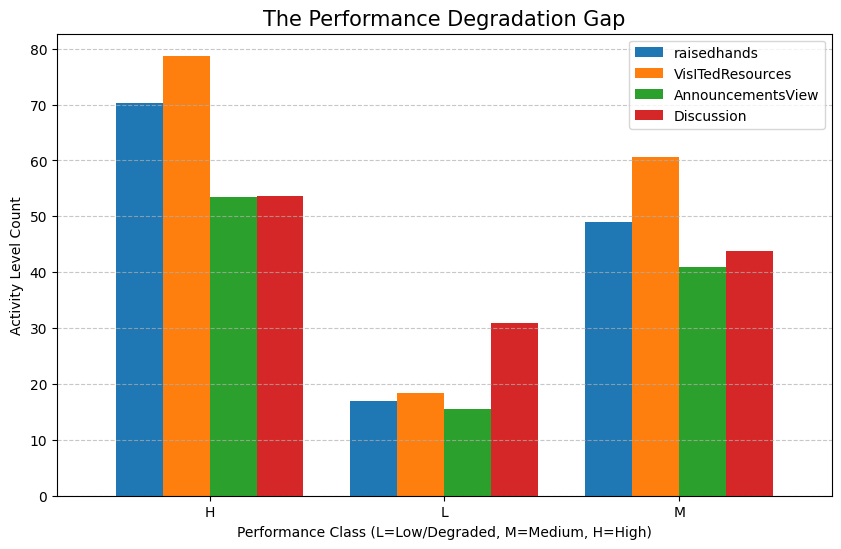

In [21]:
# 1. Check for missing data (to ensure a clean research foundation)
print("--- Data Integrity Check ---")
print(xapi_df.isnull().sum())

# 2. Statistical Proof of Performance Degradation
# We compare the average engagement of a 'High' student vs a 'Low' (Degraded) student
print("\n--- Average Human Behavior per Performance Class ---")
analysis = xapi_df.groupby('Class')[['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']].mean()
print(analysis)

# 3. Visualizing the 'Engagement Gap'
# This chart shows exactly how much activity drops when performance degrades
analysis.plot(kind='bar', figsize=(10, 6), width=0.8)
plt.title('The Performance Degradation Gap', fontsize=15)
plt.ylabel('Activity Level Count')
plt.xlabel('Performance Class (L=Low/Degraded, M=Medium, H=High)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

--- AI MODEL SUCCESS REPORT ---
Prediction Accuracy: 90.62%

Detailed Research Performance:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        22
           1       1.00      1.00      1.00        26
           2       0.90      0.92      0.91        48

    accuracy                           0.91        96
   macro avg       0.90      0.90      0.90        96
weighted avg       0.91      0.91      0.91        96



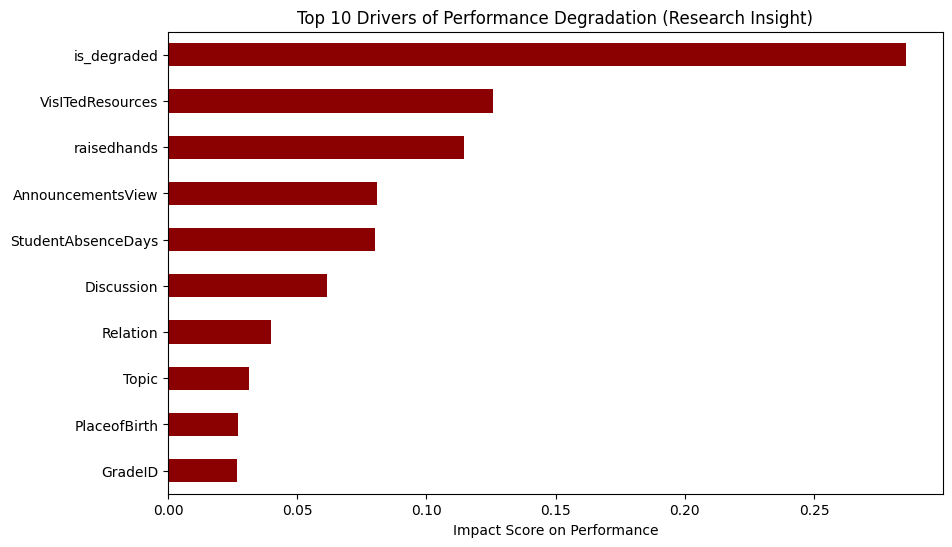

In [22]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Prepare the Data (Encoding text to numbers)
le = LabelEncoder()
df_ai = xapi_df.copy()
for col in df_ai.columns:
    if df_ai[col].dtype == 'object':
        df_ai[col] = le.fit_transform(df_ai[col])

# 2. Split into Features (X) and Target (y)
X = df_ai.drop('Class', axis=1)
y = df_ai['Class'] # Predicting L, M, or H

# 3. Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Building the Model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Proving the Results
y_pred = model.predict(X_test)
print("--- AI MODEL SUCCESS REPORT ---")
print(f"Prediction Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nDetailed Research Performance:")
print(classification_report(y_test, y_pred))

# 6. Identifying the 'Triggers' of Degradation
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='darkred')
plt.title('Top 10 Drivers of Performance Degradation (Research Insight)')
plt.xlabel('Impact Score on Performance')
plt.gca().invert_yaxis()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/tmp/ipython-input-251/3639742535.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='cool')


Random Forest Accuracy: 90.62%
Logistic Regression Accuracy: 87.50%


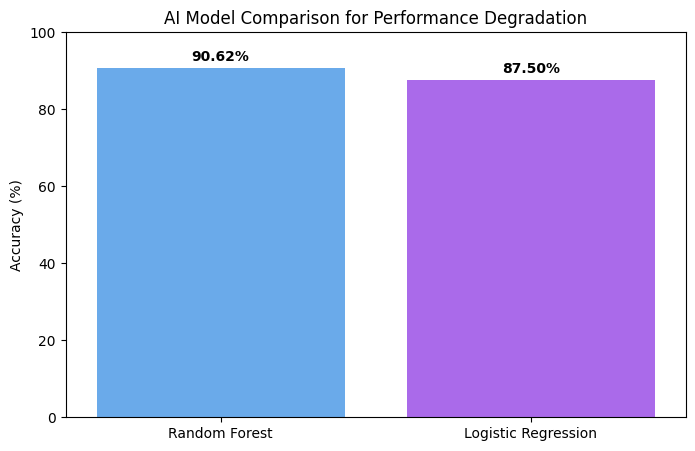

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Initialize the second model (Logistic Regression)
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# 2. Make predictions
log_pred = log_model.predict(X_test)

# 3. Compare Accuracy
rf_acc = accuracy_score(y_test, y_pred) * 100
log_acc = accuracy_score(y_test, log_pred) * 100

print(f"Random Forest Accuracy: {rf_acc:.2f}%")
print(f"Logistic Regression Accuracy: {log_acc:.2f}%")

# 4. Visual Comparison Chart
models = ['Random Forest', 'Logistic Regression']
accuracies = [rf_acc, log_acc]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=accuracies, palette='cool')
plt.ylim(0, 100)
plt.title('AI Model Comparison for Performance Degradation')
plt.ylabel('Accuracy (%)')
for i, v in enumerate(accuracies):
    plt.text(i, v + 2, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

In [24]:
from sklearn.model_selection import cross_val_score

# Performing 5-Fold Cross Validation on our best model (Random Forest)
scores = cross_val_score(model, X, y, cv=5)

print("--- Robustness Check (Cross-Validation) ---")
print(f"Individual Fold Scores: {scores}")
print(f"Mean Accuracy: {scores.mean() * 100:.2f}%")
print(f"Standard Deviation: {scores.std():.4f}")

# Research Note: A low standard deviation means your AI model is very reliable.

--- Robustness Check (Cross-Validation) ---
Individual Fold Scores: [0.80208333 0.73958333 0.83333333 0.875      0.71875   ]
Mean Accuracy: 79.38%
Standard Deviation: 0.0580


In [25]:
def predict_student_status(model, student_data):
    prediction = model.predict([student_data])
    classes = {0: 'High', 1: 'Low (Degraded)', 2: 'Medium'}
    return classes[prediction[0]]

# Example: Let's test a "High Risk" student
# (We use the first row of X_test as an example)
sample_student = X_test.iloc[0]
result = predict_student_status(model, sample_student)

print(f"The AI predicts this student will have: {result} Performance.")

The AI predicts this student will have: Medium Performance.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
